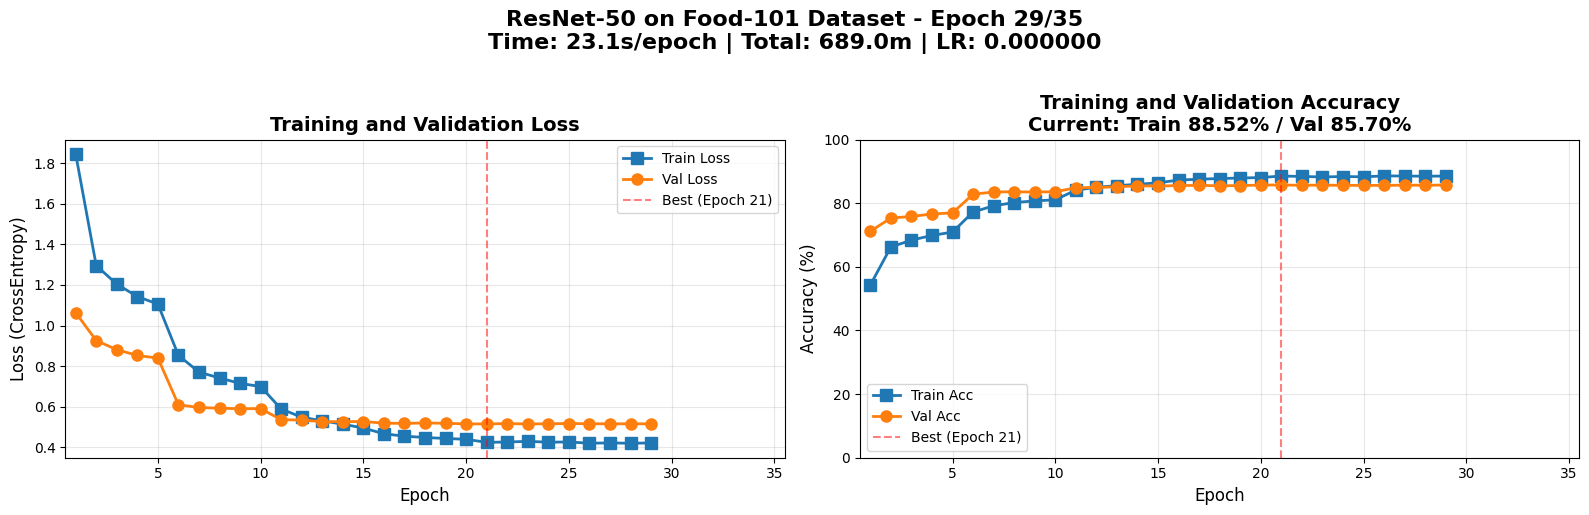


Epoch 29/35 Summary:
Train Loss: 0.4214 | Train Acc: 88.52%
Val Loss:   0.5156 | Val Acc:   85.70%
Best Val Loss: 0.5150 at Epoch 21
Learning Rate: 0.000000
Time: 23.1s | Total Time: 689.0m

Epoch 30/35 [====>.........................] - 42/295 - loss: 0.4079 - acc: 0.8879

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import numpy as np
import random
import sys
import time
import h5py
from sklearn.metrics import classification_report, confusion_matrix
# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

os.environ["WANDB_DISABLED"] = "true"

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# ============================================================
# PATHS CONFIGURATION
# ============================================================
FOOD101_ROOT = "/kaggle/input/dataset-for-nutridish-project/Model_Training/datasets/food101/"
IMAGES_DIR = os.path.join(FOOD101_ROOT, "images")
META_DIR = os.path.join(FOOD101_ROOT, "meta")

# Verify paths exist
assert os.path.isdir(IMAGES_DIR), f"Images folder not found: {IMAGES_DIR}"
assert os.path.isdir(META_DIR), f"Meta folder not found: {META_DIR}"

# Read all classes
with open(os.path.join(META_DIR, "classes.txt")) as f:
    CLASS_LIST = [line.strip() for line in f if line.strip()]

NUM_CLASSES = len(CLASS_LIST)
CLASS_TO_INDEX = {c: i for i, c in enumerate(CLASS_LIST)}
print(f"Total classes: {NUM_CLASSES}")

# ============================================================
# BUILD DATASET
# ============================================================
def read_meta_file(filepath):
    """Read train.txt or test.txt"""
    with open(filepath, "r") as f:
        return [l.strip() for l in f if l.strip()]

train_list = read_meta_file(os.path.join(META_DIR, "train.txt"))
test_list = read_meta_file(os.path.join(META_DIR, "test.txt"))
print(f"Train entries: {len(train_list)}, Test entries: {len(test_list)}")

def build_dataset_entries(list_paths, root):
    """Build list of (image_path, label_index) tuples"""
    entries = []
    for rel in list_paths:
        img_path = os.path.join(root, rel + ".jpg") if not rel.endswith(".jpg") else os.path.join(root, rel)
        if not os.path.exists(img_path): 
            continue
        class_name = rel.split("/")[0]
        if class_name not in CLASS_TO_INDEX: 
            continue
        entries.append((img_path, CLASS_TO_INDEX[class_name]))
    return entries

train_entries = build_dataset_entries(train_list, IMAGES_DIR)
test_entries = build_dataset_entries(test_list, IMAGES_DIR)
print(f"Train entries used: {len(train_entries)}, Test entries used: {len(test_entries)}")

# ============================================================
# CUSTOM DATASET CLASS
# ============================================================
class Food101Dataset(Dataset):
    def __init__(self, entries, transform=None):
        """
        Args:
            entries: List of (image_path, label_index) tuples
            transform: Optional transform to be applied on images
        """
        self.entries = entries
        self.transform = transform
    
    def __len__(self):
        return len(self.entries)
    
    def __getitem__(self, idx):
        img_path, label = self.entries[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# ============================================================
# DATA TRANSFORMATIONS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),  
    transforms.RandomAffine(0, translate=(0.08, 0.08), scale=(0.95, 1.05)),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),  
    transforms.RandomGrayscale(p=0.05),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = Food101Dataset(entries=train_entries, transform=train_transform)
val_dataset = Food101Dataset(entries=test_entries, transform=val_transform)

# Create data loaders
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    drop_last=True
)

print(f"\nNumber of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of classes: {NUM_CLASSES}")

# Test the dataloader
for images, labels in train_loader:
    print(f"\nTrain batch shape: {images.shape}")
    print(f"Train labels shape: {labels.shape}")
    break

for images, labels in val_loader:
    print(f"Val batch shape: {images.shape}")
    print(f"Val labels shape: {labels.shape}")
    break

# ============================================================
# VISUALIZE SAMPLE IMAGES
# ============================================================
num_rows = 3
num_cols = 5
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 12))

# Get random indices
indices = random.sample(range(len(train_dataset)), num_rows * num_cols)

for idx, ax in enumerate(axes.flat):
    # Get image and label
    img, label = train_dataset[indices[idx]]
    
    # Denormalize the image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    
    # Convert to PIL Image and then numpy array
    img = transforms.ToPILImage()(img.clamp(0, 1))
    img = np.array(img)
    
    # Plot
    ax.imshow(img)
    ax.set_title(CLASS_LIST[label], pad=5)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# MODEL SETUP
# ============================================================
weights = torchvision.models.ResNet50_Weights.DEFAULT
resnet = torchvision.models.resnet50(weights=weights)
summary(resnet.to(device), (3, 224, 224))

# Modify the final layer with dropout
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),  
    nn.Linear(resnet.fc.in_features, NUM_CLASSES)
)

# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze specific layers
for name, param in resnet.named_parameters():
    if any(x in name for x in ['layer4', 'fc']): 
        param.requires_grad = True

resnet.to(device)

# ============================================================
# TRAINING SETUP
# ============================================================
lr = 0.001
l2 = 1e-3
lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.parameters(), lr=lr, weight_decay=l2)

# StepLR - reduces learning rate by a factor at specified intervals
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,        # Reduce LR every 5 epochs
    gamma=0.2          # Reduce LR by factor of 0.2
)

# ============================================================
# TRAINING FUNCTION WITH VISUALIZATION
# ============================================================
def train_model():
    numepochs = 35
     
    # Initialize losses / accuracies
    trainLoss = torch.zeros(numepochs)
    valLoss = torch.zeros(numepochs)
    trainAcc = torch.zeros(numepochs)
    valAcc = torch.zeros(numepochs)
    
    # Best model tracking
    best_val_loss = float('inf')
    best_epoch = 0
    
    # Setup live plotting
    from IPython.display import clear_output
    
    start_time = time.time()
    for epochi in range(numepochs):
        epoch_start_time = time.time()
        
        # Train mode
        resnet.train()
        
        # Training with progress bar
        batch_train_loss = []
        batch_train_acc = []
        num_batches = len(train_loader)
        
        for batch_idx, (X, y) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            
            yHat = resnet(X)
            loss = lossfun(yHat, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            batch_train_loss.append(loss.item())
            batch_train_acc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())
            
            # Progress bar
            progress = (batch_idx + 1) / num_batches
            bar_length = 30
            filled = int(bar_length * progress)
            bar = '=' * filled + '>' * (progress < 1) + '.' * (bar_length - filled - 1)
            
            sys.stdout.write(f"\rEpoch {epochi+1}/{numepochs} "
                           f"[{bar}] - "
                           f"{batch_idx+1}/{num_batches} - "
                           f"loss: {np.mean(batch_train_loss):.4f} - "
                           f"acc: {np.mean(batch_train_acc):.4f}")
            sys.stdout.flush()
        
        trainLoss[epochi] = np.mean(batch_train_loss)
        trainAcc[epochi] = 100 * np.mean(batch_train_acc)
        
        # Eval mode
        resnet.eval()
        
        with torch.no_grad():
            batch_val_loss = []
            batch_val_acc = []
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                
                yHat = resnet(X)
                loss = lossfun(yHat, y)
                
                batch_val_loss.append(loss.item())
                batch_val_acc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())
            
            valLoss[epochi] = np.mean(batch_val_loss)
            valAcc[epochi] = 100 * np.mean(batch_val_acc)
        
        # Step the scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        epoch_time = (time.time() - epoch_start_time) / 60
        total_time = (time.time() - start_time) / 60
        
        # Check if this is the best model
        improved = ""
        if valLoss[epochi] < best_val_loss:
            best_val_loss = valLoss[epochi]
            best_epoch = epochi + 1
            improved = " - val_loss improved, saving model"
            
            # Save best model
            output_dir = '/kaggle/working/'
            model_path = os.path.join(output_dir, 'best_food101_model.pth')
            best_model_state = {
                'epoch': epochi + 1,
                'model_state_dict': resnet.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': trainLoss[epochi].item(),
                'val_loss': valLoss[epochi].item(),
                'train_acc': trainAcc[epochi].item(),
                'val_acc': valAcc[epochi].item(),
                'class_list': CLASS_LIST,
                'class_to_index': CLASS_TO_INDEX,
                'num_classes': NUM_CLASSES
            }
            torch.save(best_model_state, model_path)
        
        # Print epoch summary
        print(f"\nEpoch {epochi+1}/{numepochs} - "
              f"{epoch_time:.0f}s - "
              f"loss: {trainLoss[epochi]:.4f} - "
              f"acc: {trainAcc[epochi]/100:.4f} - "
              f"val_loss: {valLoss[epochi]:.4f} - "
              f"val_acc: {valAcc[epochi]/100:.4f}{improved}")
        
        # Live plotting every epoch
        if (epochi + 1) % 1 == 0:  # Plot every epoch
            clear_output(wait=True)
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            epochs_so_far = epochi + 1
            x_data = np.arange(1, epochs_so_far + 1)
            
            # Loss plot
            axes[0].plot(x_data, trainLoss[:epochs_so_far].numpy(), 's-', 
                        label='Train Loss', linewidth=2, markersize=8)
            axes[0].plot(x_data, valLoss[:epochs_so_far].numpy(), 'o-', 
                        label='Val Loss', linewidth=2, markersize=8)
            axes[0].axvline(x=best_epoch, color='red', linestyle='--', 
                           alpha=0.5, label=f'Best (Epoch {best_epoch})')
            axes[0].set_xlabel('Epoch', fontsize=12)
            axes[0].set_ylabel('Loss (CrossEntropy)', fontsize=12)
            axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
            axes[0].legend(fontsize=10)
            axes[0].grid(True, alpha=0.3)
            axes[0].set_xlim(0.5, numepochs + 0.5)
            
            # Accuracy plot
            axes[1].plot(x_data, trainAcc[:epochs_so_far].numpy(), 's-', 
                        label='Train Acc', linewidth=2, markersize=8)
            axes[1].plot(x_data, valAcc[:epochs_so_far].numpy(), 'o-', 
                        label='Val Acc', linewidth=2, markersize=8)
            axes[1].axvline(x=best_epoch, color='red', linestyle='--', 
                           alpha=0.5, label=f'Best (Epoch {best_epoch})')
            axes[1].set_xlabel('Epoch', fontsize=12)
            axes[1].set_ylabel('Accuracy (%)', fontsize=12)
            axes[1].set_title(f'Training and Validation Accuracy\n'
                            f'Current: Train {trainAcc[epochi]:.2f}% / Val {valAcc[epochi]:.2f}%',
                            fontsize=14, fontweight='bold')
            axes[1].legend(fontsize=10)
            axes[1].grid(True, alpha=0.3)
            axes[1].set_xlim(0.5, numepochs + 0.5)
            axes[1].set_ylim(0, 100)
            
            fig.suptitle(f'ResNet-50 on Food-101 Dataset - Epoch {epochi+1}/{numepochs}\n'
                        f'Time: {epoch_time:.1f}s/epoch | Total: {total_time:.1f}m | LR: {current_lr:.6f}',
                        fontsize=16, fontweight='bold', y=1.02)
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n{'='*80}")
            print(f"Epoch {epochi+1}/{numepochs} Summary:")
            print(f"{'='*80}")
            print(f"Train Loss: {trainLoss[epochi]:.4f} | Train Acc: {trainAcc[epochi]:.2f}%")
            print(f"Val Loss:   {valLoss[epochi]:.4f} | Val Acc:   {valAcc[epochi]:.2f}%")
            print(f"Best Val Loss: {best_val_loss:.4f} at Epoch {best_epoch}")
            print(f"Learning Rate: {current_lr:.6f}")
            print(f"Time: {epoch_time:.1f}s | Total Time: {total_time:.1f}m")
            print(f"{'='*80}\n")
    
    print("\n" + "="*80)
    print("TRAINING COMPLETED!")
    print("="*80)
    print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Final train accuracy: {trainAcc[-1]:.2f}%")
    print(f"Final validation accuracy: {valAcc[-1]:.2f}%")
    print(f"Total training time: {total_time:.2f} minutes")
    print("="*80)
    
    # Save final model
    output_dir = '/kaggle/working/'
    model_path = os.path.join(output_dir, 'food101_final_model.pth')
    
    final_model_state = {
        'epoch': numepochs,
        'model_state_dict': resnet.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': trainLoss[-1].item(),
        'val_loss': valLoss[-1].item(),
        'train_acc': trainAcc[-1].item(),
        'val_acc': valAcc[-1].item(),
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'class_list': CLASS_LIST,
        'class_to_index': CLASS_TO_INDEX,
        'num_classes': NUM_CLASSES,
        'all_train_losses': trainLoss.tolist(),
        'all_val_losses': valLoss.tolist(),
        'all_train_accs': trainAcc.tolist(),
        'all_val_accs': valAcc.tolist()
    }
    torch.save(final_model_state, model_path)
    print(f"\nFinal model saved to: {model_path}")
    print(f"Best model saved to: {os.path.join(output_dir, 'best_food101_model.pth')}")
    
    return trainLoss, valLoss, trainAcc, valAcc

# Train the model
trainLoss, valLoss, trainAcc, valAcc = train_model()

# ============================================================
# FINAL PLOT
# ============================================================
print("\n" + "="*80)
print("FINAL TRAINING RESULTS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
axes[0].plot(range(1, len(trainLoss)+1), trainLoss.numpy(), 's-', 
            label='Train Loss', linewidth=2.5, markersize=8)
axes[0].plot(range(1, len(valLoss)+1), valLoss.numpy(), 'o-', 
            label='Val Loss', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (CrossEntropy)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Loss Over Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(range(1, len(trainAcc)+1), trainAcc.numpy(), 's-', 
            label='Train Acc', linewidth=2.5, markersize=8)
axes[1].plot(range(1, len(valAcc)+1), valAcc.numpy(), 'o-', 
            label='Val Acc', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Model Accuracy Over Training\n'
                 f'Final: Train {trainAcc[-1]:.2f}% / Val {valAcc[-1]:.2f}%',
                 fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 100)

fig.suptitle('Pretrained ResNet-50 on Food-101 Dataset - Training Complete', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTraining history plot saved to: /kaggle/working/training_history.png")

# ============================================================
# MODEL LOADING FUNCTION
# ============================================================
def load_model(model_path='/kaggle/working/best_food101_model.pth'):
    """Load trained model from checkpoint"""
    # Initialize the model architecture
    model = torchvision.models.resnet50()
    
    # Load the saved state
    checkpoint = torch.load(model_path)
    num_classes = checkpoint['num_classes']
    
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes)
    )
    
    model.load_state_dict(checkpoint['model_state_dict'])
    class_list = checkpoint['class_list']
    
    model = model.to(device)
    model.eval()
    
    print(f"\nModel loaded from: {model_path}")
    if 'epoch' in checkpoint:
        print(f"Epoch: {checkpoint['epoch']}")
        print(f"Train Loss: {checkpoint['train_loss']:.4f} | Train Acc: {checkpoint['train_acc']:.2f}%")
        print(f"Val Loss: {checkpoint['val_loss']:.4f} | Val Acc: {checkpoint['val_acc']:.2f}%")
    
    return model, class_list

# ============================================================
# EVALUATION FUNCTION
# ============================================================
def evaluate_model():
    """Evaluate model with detailed metrics"""
    model, class_list = load_model()
    
    print("\n" + "="*60)
    print("EVALUATING MODEL")
    print("="*60)
    
    all_predictions = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Overall accuracy
    accuracy = 100 * (all_predictions == all_labels).sum() / len(all_labels)
    print(f"\nOverall Test Accuracy: {accuracy:.2f}%")
    
    # Classification report
    report = classification_report(
        all_labels, 
        all_predictions, 
        target_names=class_list,
        digits=3
    )
    print("\nClassification Report:")
    print(report)
    
    # Per-class accuracy
    cm = confusion_matrix(all_labels, all_predictions)
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    # Get best and worst performing classes
    class_accuracies = list(zip(class_list, per_class_accuracy))
    class_accuracies.sort(key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 Best Performing Classes:")
    for class_name, acc in class_accuracies[:10]:
        print(f"  {class_name}: {acc*100:.2f}%")
    
    print("\nTop 10 Worst Performing Classes:")
    for class_name, acc in class_accuracies[-10:]:
        print(f"  {class_name}: {acc*100:.2f}%")

# Run evaluation
evaluate_model()